In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier


In [31]:
# Loading dataset
df = pd.read_csv("loandataset.csv")

# I am looking at the first few rows to see the raw formatting
print("First 5 rows of the raw data:")
display(df.head())

# I am checking the data types and looking for missing values
print("\nSummary of the dataset structure:")
df.info()

# I am counting exactly how many missing values exist in each column
print("\nCount of missing values per column:")
print(df.isnull().sum())

First 5 rows of the raw data:


,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT



Summary of the dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  object 
 3   home_ownership       32586 non-null  object 
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  object 
 6   loan_grade           32586 non-null  object 
 7   loan_amnt            32585 non-null  object 
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  object 
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 3.2+ MB

Count of missing values per column:
custome

In [32]:
# Standardizing all column names to lowercase
df.columns = df.columns.str.strip().str.lower()

# Removing £ symbols and commas from numeric columns
cols_to_fix = ['customer_income', 'loan_amnt', 'loan_int_rate']
for col in cols_to_fix:
    if col in df.columns:
        # I am converting to string first, then stripping symbols, then forcing to numeric
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('£', '').str.replace(',', ''), errors='coerce')

# Dropping the customer_id
df = df.drop('customer_id', axis=1, errors='ignore')

# Mapping binary categories to 1 and 0
if 'historical_default' in df.columns:
    df['historical_default'] = df['historical_default'].map({'Y': 1, 'N': 0, 'y': 1, 'n': 0})

if 'current_loan_status' in df.columns:
    df['current_loan_status'] = df['current_loan_status'].map({'DEFAULT': 1, 'NO DEFAULT': 0, 'default': 1, 'no default': 0})

# Converting text categories into numeric columns
cat_cols = ['home_ownership', 'loan_intent', 'loan_grade']
df = pd.get_dummies(df, columns=[c for c in cat_cols if c in df.columns], drop_first=True)

# First, I fill missing values with the median
df = df.fillna(df.median())

# Second, I fill any remaining blanks (if median failed) with 0
df = df.fillna(0)

# Finally, I drop any columns that might still have a NaN just in case
df = df.dropna(axis=1)

# Ensuring all data is in float format
df = df.astype(float)

# I am printing the count of NaNs here.
print(f"Total missing values in the entire table: {df.isnull().sum().sum()}")
df.head()

Total missing values in the entire table: 0


,customer_age,customer_income,employment_duration,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,current_loan_status,home_ownership_OTHER,...,home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E
0,22.0,59000.0,123.0,35000.0,16.02,10.0,1.0,3.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,21.0,9600.0,5.0,1000.0,11.14,1.0,1.0,2.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25.0,9600.0,1.0,5500.0,12.87,5.0,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,10.0,0.0,2.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,24.0,54400.0,8.0,35000.0,14.27,10.0,1.0,4.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


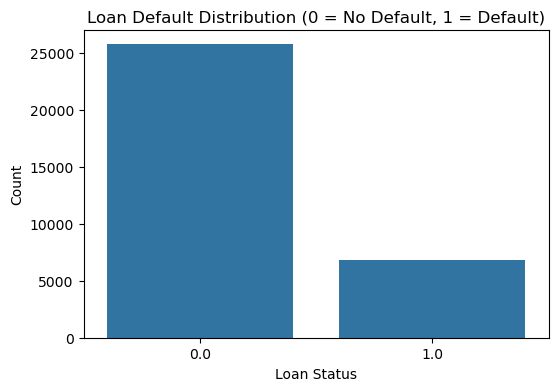

current_loan_status
0.0    0.790094
1.0    0.209906
Name: proportion, dtype: float64


In [33]:
#Bar graph to check the distribution of default loans
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Loan Default Distribution (0 = No Default, 1 = Default)")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

print(y.value_counts(normalize=True))

In [34]:
# Defining the features (X) and the target variable (y)
X = df.drop('current_loan_status', axis=1)
y = df['current_loan_status']

# Splitting the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split. Training rows: {len(X_train)}")

Data split. Training rows: 26068


In [35]:
# 1. Training the Logistic Regression model
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

# 2. Training the Decision Tree model
# I am setting a max_depth so the tree doesn't get too "crazy" and over-fit
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 3. Training the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Logistic, Decision Tree, and Random Forest models are trained.")

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic, Decision Tree, and Random Forest models are trained.


In [36]:

# I am getting predictions from each of my three models
log_preds = log_model.predict(X_test)
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# --- 1. Logistic Regression Metrics ---
print("--- Logistic Regression Metrics ---")
print(f"Accuracy Score:  {accuracy_score(y_test, log_preds):.2%}")
print(f"Precision Score: {precision_score(y_test, log_preds):.2%}")
print(f"Recall Score:    {recall_score(y_test, log_preds):.2%}")
print(f"F1-Score:        {f1_score(y_test, log_preds):.2%}")
print("\n")

# --- 2. Decision Tree Metrics ---
print("--- Decision Tree Metrics ---")
print(f"Accuracy Score:  {accuracy_score(y_test, dt_preds):.2%}")
print(f"Precision Score: {precision_score(y_test, dt_preds):.2%}")
print(f"Recall Score:    {recall_score(y_test, dt_preds):.2%}")
print(f"F1-Score:        {f1_score(y_test, dt_preds):.2%}")
print("\n")

# --- 3. Random Forest Metrics ---
print("--- Random Forest Metrics ---")
print(f"Accuracy Score:  {accuracy_score(y_test, rf_preds):.2%}")
print(f"Precision Score: {precision_score(y_test, rf_preds):.2%}")
print(f"Recall Score:    {recall_score(y_test, rf_preds):.2%}")
print(f"F1-Score:        {f1_score(y_test, rf_preds):.2%}")

--- Logistic Regression Metrics ---
Accuracy Score:  92.02%
Precision Score: 86.39%
Recall Score:    73.84%
F1-Score:        79.62%


--- Decision Tree Metrics ---
Accuracy Score:  93.79%
Precision Score: 94.02%
Recall Score:    75.36%
F1-Score:        83.66%


--- Random Forest Metrics ---
Accuracy Score:  96.39%
Precision Score: 97.34%
Recall Score:    85.25%
F1-Score:        90.90%


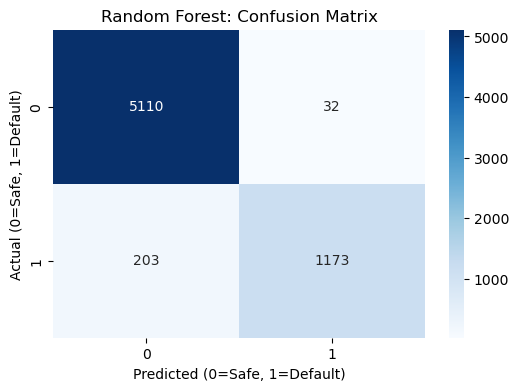

In [37]:
# I am plotting the confusion matrix for the Random Forest model
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest: Confusion Matrix')
plt.xlabel('Predicted (0=Safe, 1=Default)')
plt.ylabel('Actual (0=Safe, 1=Default)')
plt.show()

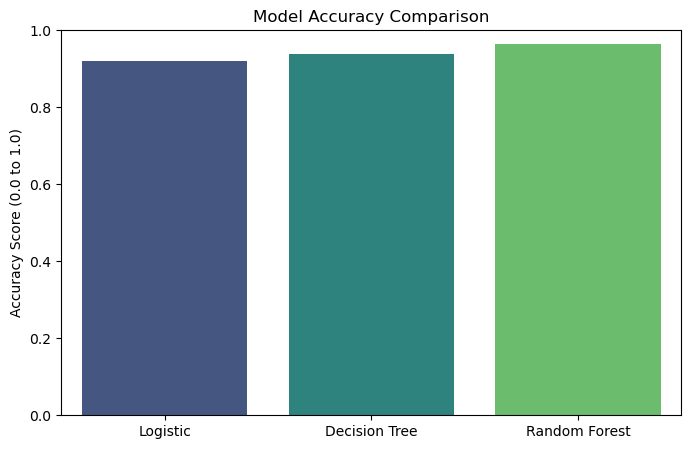

In [ ]:
# I am setting the labels for my three models
model_names = ['Logistic', 'Decision Tree', 'Random Forest']

# I am collecting the accuracy scores for each model
scores = [
    accuracy_score(y_test, log_preds), 
    accuracy_score(y_test, dt_preds), 
    accuracy_score(y_test, rf_preds)
]

# I am plotting the comparison bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=scores, hue=model_names, palette='viridis', legend=False)

# I am adding labels to make the chart easy to read
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score (0.0 to 1.0)')
plt.ylim(0, 1) # I am setting the limit to 100% for a fair comparison
plt.show()

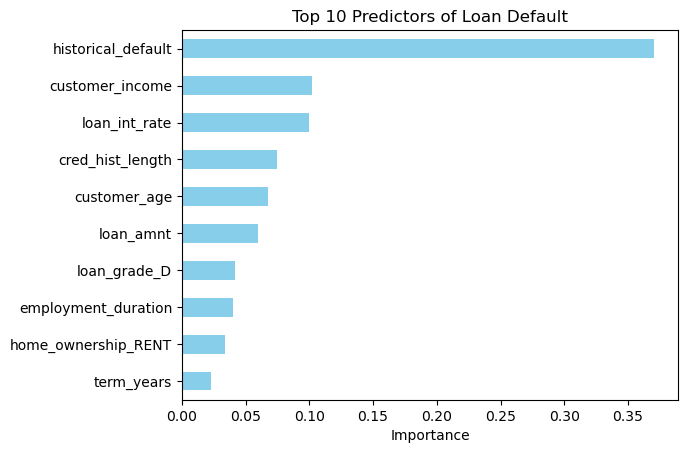

In [39]:
# Plotting the feature importance from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Predictors of Loan Default')
plt.xlabel('Importance')
plt.show()